In [1]:
# # # # 获取数据集Energy均值和标准差
import lmdb
import pickle
import numpy as np

lmdb_p = '/media/liud/lnz_2t/OC22/is2res_total_train_val_test_lmdbs/data/oc22/is2re/train'
env = lmdb.open(lmdb_p, map_size=1099511627776, readonly=True, lock=False)
# # # # 获取数据集均值和标准差
import torch
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    y_list = []
    for key, value in cursor:
        info = pickle.loads(value)
        y_list.append(info.y)
    y_list = torch.tensor(y_list)
    target_mean = torch.mean(y_list, dim=0)
    target_std = torch.std(y_list, dim=0)
    print(target_mean)
    # print(target_mean, target_std)
    print(target_std)

tensor(-523.8716, dtype=torch.float64)
tensor(228.1776, dtype=torch.float64)


In [13]:
# # # # 获取数据集Vetor均值和标准差
import lmdb
import pickle
import numpy as np

lmdb_p = '/media/liud/lnz_2t/OC20/is2re/100k/tags12/50k/test'
env = lmdb.open(lmdb_p, map_size=1099511627776, readonly=True, lock=False)
import torch
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    y_list = []
    d_max = []
    for key, value in cursor:
        info = pickle.loads(value)
        pos1 = info.pos
        pos2 = info.pos_relaxed
        dist = torch.norm(pos2-pos1, dim=1).unsqueeze(0)
        d_max.append(torch.max(dist))
        dist = dist.tolist()
        y_list.extend(dist[0])
        # tags = info.tags
        # tags12 = torch.where(tags > 0)[0]
        # src, dst = info.edge_index
        # cond1 = torch.isin(src, tags12)
        # cond2 = torch.isin(dst, tags12)
        # # 结合所有条件，生成一个布尔掩码
        # mask = cond1 | cond2
        # v = info.v1[mask]
        # v = info.v1
        # y_list.extend(v.tolist())
    print(len(d_max))
    print(len(y_list))
    # y_list = torch.tensor(y_list)
    # target_mean = torch.mean(y_list, dim=0)
    # target_std = torch.std(y_list, dim=0)
    # print(target_mean)
    # # print(target_mean, target_std)
    # print(target_std)

10000
251679


In [103]:
# 查看lmdb中的数据
import lmdb
import pickle
import numpy as np
from ase.visualize import view
from ase import Atoms

lmdb_p = "/media/liud/lnz_2t/OC20/is2re/100k/origin/ac/train"
env = lmdb.open(lmdb_p, map_size=1099511627776, readonly=True, lock=False)
# 遍历所有键值对，并只打印前 5 个数据
print("First 5 entries in the database:")
count = 0
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        if value is not None:
            try:
                data = pickle.loads(value)
                print(f"Key: {key.decode()}")
                print("Data:", data)
                # print(data.pos)
                # print(data.pos_relaxed)
                print(data.atomic_numbers)
                # print(data.sid)
                print(data.tags)
                # print(data.cell)
                atoms = Atoms(positions=data.pos, cell=data.cell[0], numbers=data.atomic_numbers)
                view(atoms)
                print(data.fixed)
                # print(data.ptr)
                # print("atomic_numbers:", type(data.atomic_numbers))
                # print("y", type(data.y))
                # print('sid', type(data.sid))
                # print("tags:", data.tags)
                # print("tags:", data.v0)
                # print("tags:", data.v1)
                # print(data.edge_index[1][0:300])
                # print("pos:", type(data.pos))
                # print(("distances:", len(data.distances)))
                # print("edge_index:", type(data.edge_index))
                # print("distances:", type(data.distances))
                # print("features:", type(data.features))
            except Exception as e:
                print(f"Error processing key {key}: {e}")
        else:
            print(f"No data found for key: {key.decode()}")
        count += 1
        if count >= 2:
            break



First 5 entries in the database:
Key: 0
Data: Data(edge_index=[2, 1104], y=-1.4450869300000022, pos=[20, 3], y_init=2.398781430000014, y_relaxed=-1.4450869300000022, pos_relaxed=[20, 3], force=[20, 3], atomic_numbers=[20], natoms=20, tags=[20], fixed=[20], distances=[1104], cell_offsets=[1104, 3], cell=[1, 3, 3], sid=719963)
tensor([40, 40, 40, 40, 40, 40, 40, 40, 40, 49, 49, 49, 49, 49, 49, 49, 49,  7,
         7,  8], dtype=torch.int16)
tensor([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 2, 2],
       dtype=torch.int16)
tensor([1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0],
       dtype=torch.int16)
Key: 1
Data: Data(edge_index=[2, 936], y=-1.1815158100000076, pos=[18, 3], y_init=0.5157478900000001, y_relaxed=-1.1815158100000076, pos_relaxed=[18, 3], force=[18, 3], atomic_numbers=[18], natoms=18, tags=[18], fixed=[18], distances=[936], cell_offsets=[936, 3], cell=[1, 3, 3], sid=273719)
tensor([11, 11, 52, 11, 52, 52, 52, 11, 52,  6, 11, 11,  6, 11,  1,  1,  1,

In [5]:
# 计算lmdb文件中的数据条目数
import lmdb

def count_entries_in_lmdb(lmdb_path):
    env = lmdb.open(lmdb_path, readonly=True, lock=False)
    with env.begin() as txn:
        cursor = txn.cursor()
        count = sum(1 for _ in cursor)
    return count

if __name__ == "__main__":
    lmdb_path = "/media/liud/lnz_2t/OC20/is2res_train_val_test_lmdbs/data/is2re/all/train"  # 替换为你的LMDB文件路径
    num_entries = count_entries_in_lmdb(lmdb_path)
    print(f"Number of entries in the LMDB file: {num_entries}")


KeyboardInterrupt: 

In [16]:
# 读取pt文件
import torch
data = torch.load("/home/liud/Documents/code/ocp/configs/s2ef/all/gemnet/scaling_factors/gemnet-oc_1.pt")
print(data)

{'int_blocks.0.trip_interaction.scale_rbf': Parameter containing:
tensor(8.6465), 'int_blocks.0.trip_interaction.scale_cbf_sum': Parameter containing:
tensor(4.6171), 'int_blocks.0.quad_interaction.scale_rbf': Parameter containing:
tensor(9.0613), 'int_blocks.0.quad_interaction.scale_cbf': Parameter containing:
tensor(30.9794), 'int_blocks.0.quad_interaction.scale_sbf_sum': Parameter containing:
tensor(8.7431), 'int_blocks.0.atom_edge_interaction.scale_rbf': Parameter containing:
tensor(8.6083), 'int_blocks.0.atom_edge_interaction.scale_cbf_sum': Parameter containing:
tensor(5.6123), 'int_blocks.0.edge_atom_interaction.scale_rbf': Parameter containing:
tensor(9.0417), 'int_blocks.0.edge_atom_interaction.scale_cbf_sum': Parameter containing:
tensor(0.5292), 'int_blocks.0.atom_interaction.scale_rbf_sum': Parameter containing:
tensor(0.5019), 'int_blocks.0.atom_update.scale_sum': Parameter containing:
tensor(0.7639), 'int_blocks.1.trip_interaction.scale_rbf': Parameter containing:
tensor(

In [24]:
import numpy as np

# 加载 .npz 文件
data = np.load('/home/liud/Documents/code/ocp/results/is2re/all_evalai/submission_file.npz')

# 查看有哪些键（相当于字典的 key）
print("Keys in the .npz file:", data.files)

# 逐个读取数据
for key in data.files:
    print(f"{key}: shape = {data[key].shape}, dtype = {data[key].dtype}")
    # 如果想看具体值，可以打印前几项
    print(data[key][:5])  # 只打印前 5 个，避免太大

Keys in the .npz file: ['id_ids', 'id_energy', 'ood_ads_ids', 'ood_ads_energy', 'ood_cat_ids', 'ood_cat_energy', 'ood_both_ids', 'ood_both_energy']
id_ids: shape = (24948,), dtype = <U7
['252' '1133' '1208' '1417' '1510']
id_energy: shape = (24948,), dtype = float32
[-1.0234079  -1.9738832  -5.06927    -0.19715816 -1.3045686 ]
ood_ads_ids: shape = (24930,), dtype = <U7
['484' '4591' '5691' '5857' '6167']
ood_ads_energy: shape = (24930,), dtype = float32
[-4.0248404  -2.3123052   0.5974349   0.53319854  0.6967316 ]
ood_cat_ids: shape = (24965,), dtype = <U7
['993' '2026' '2362' '3498' '4762']
ood_cat_energy: shape = (24965,), dtype = float32
[-2.4762337   0.27786833  0.03296276  0.3324662  -0.89956474]
ood_both_ids: shape = (24985,), dtype = <U7
['1485' '2842' '5804' '7455' '12704']
ood_both_energy: shape = (24985,), dtype = float32
[ 0.14635512 -0.6726208  -3.2316308   0.34344596 -2.6953106 ]


In [9]:
import numpy as np

# 加载 npz 文件
data = np.load('/home/liud/Documents/code/ocp/results/is2re/all_evalai/test_ood_both/is2re_predictions_0.npz')

# 提取 'ids' 数组（假设 ids 是数字字符串）
ids = data['ids']

# 将 'ids' 转换为整数进行排序
sorted_indices = np.argsort(ids.astype(int))  # 获取排序后的索引

# 根据排序后的索引重新排列其他数据
# 例如，假设你有一个名为 'features' 的数组需要按 'ids' 排序
energy = data['energy'][sorted_indices]


# 打印排序后的数据（可选）
print("Sorted ids:", ids[sorted_indices][0:10])
print("Sorted features:", energy[0:10])

# 如果需要保存排序后的数据
np.savez('/home/liud/Documents/code/ocp/results/is2re/all_evalai/test_ood_both/is2re_predictions.npz', ids=ids[sorted_indices], energy=energy)

Sorted ids: ['1485' '2842' '5804' '7455' '12704' '14671' '21992' '23015' '35680'
 '42826']
Sorted features: [ 0.14635512 -0.6726208  -3.2316308   0.34344596 -2.6953106  -3.1612942
 -2.4497426  -2.8742888  -3.2049856  -1.6749876 ]


In [23]:
import lmdb
import numpy as np
import pickle

# 读取 LMDB 文件
def read_lmdb_sids(lmdb_file):
    env = lmdb.open(lmdb_file, readonly=True)
    with env.begin() as txn:
        cursor = txn.cursor()
        sids = []
        for key, value in cursor:
            # 假设每个数据项是一个字典，且包含 'sid' 属性
            data = pickle.loads(value)  # 示例，根据具体数据类型调整
            sid = data.sid  # 假设数据是一个包含sid的字典
            if sid is not None:
                sids.append(sid)
        return sids

# 读取 npz 文件中的 ids 属性
def read_npz_ids(npz_file):
    data = np.load(npz_file)
    return data['ids']

# 比较 LMDB 中的 sid 和 npz 中的 ids 是否一致
def compare_sids_with_ids(lmdb_file, npz_file):
    lmdb_sids = np.array(read_lmdb_sids(lmdb_file), dtype=np.int32)
    npz_ids = np.array(read_npz_ids(npz_file), dtype=np.int32)
    
    # 比较这两个列表
    if sorted(lmdb_sids) == sorted(npz_ids):
        print("LMDB 和 NPZ 文件中的 ids 一致")
    else:
        print("LMDB 和 NPZ 文件中的 ids 不一致")

# 示例调用
lmdb_file = '/media/liud/lnz_2t/OC20/is2re/all/tags12/origin/test_ood_both'
npz_file = '/home/liud/Documents/code/ocp/results/is2re/all_evalai/test_ood_both/is2re_predictions.npz'
compare_sids_with_ids(lmdb_file, npz_file)

LMDB 和 NPZ 文件中的 ids 一致


In [26]:
# checkpoint scale_dict保存为pt文件
import torch

# 加载已有 checkpoint
checkpoint = torch.load("/media/liud/lnz_2t/all_128b", map_location="cpu")
# print(checkpoint)
scale_dict = {}
for k, v in checkpoint['state_dict'].items():
    if 'scale_factor' in k:
        key = k.replace('module.', '')  # 去除 'module.' 前缀
        key = key.rsplit('.scale_factor', 1)[0]
        scale_dict[key] = torch.nn.Parameter(v.clone().detach().to(torch.float32), requires_grad=False)

torch.save(scale_dict, '/home/liud/Documents/code/ocp/configs/s2ef/all/gemnet/scaling_factors/fit_scale/gemnet_all_128b_energy.pt')
print('save')

save


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def gaussian_rbf(start, stop, num_rbf, d):
    offset = np.linspace(start, stop, num_rbf)
    coeff = -0.5 / ((stop-start)/(num_rbf-1))**2
    dist = d[:, None] - offset[None, :]
    return np.exp(coeff * np.power(dist, 2))

def env(scaled, d):
    a = - (scaled + 1) * (scaled + 2) / 2
    b = scaled*(scaled+2)
    c = -scaled*(scaled+1)/2
    return 1+a*d**scaled+b*d**(scaled+1)+c*d**(scaled+2)

def tanhenv(d):
    # return np.tanh(d) 
    return np.(d) 
# 参数
d = np.linspace(-1, 1, 100)
print(d)

# Envelope
# envelope = env(1, d)
envelope = tanhenv(d)
num_rbf = 32
# Gaussian RBF
rbf = gaussian_rbf(-1, 1, 32, d)
print(rbf[-1])
# 包络乘上RBF
rbf_with_envelope = rbf * envelope[:, None]
rbf_with_envelope = rbf 
# print(rbf_with_envelope[-1])

# 颜色映射
colors_list = ["#d7312d", "#f2724d", "#fee395", "#fef9b7", "#acd2e5", "#6090c1"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom", colors_list, N=64)
colors = custom_cmap(np.linspace(-1, 1, 64))

# 绘图
plt.figure(figsize=(12, 8))
for i in range(num_rbf):
    plt.scatter(d, rbf_with_envelope[:, i], color=colors[i])
plt.title("Radial Basis with Envelope (Color Gradient)")
plt.xlabel("Distance (Angstrom)")
plt.ylabel("RBF Value")
# plt.grid(False)
plt.savefig("rbf.png", dpi=300)  # 高清保存
plt.show()


[-1.         -0.97979798 -0.95959596 -0.93939394 -0.91919192 -0.8989899
 -0.87878788 -0.85858586 -0.83838384 -0.81818182 -0.7979798  -0.77777778
 -0.75757576 -0.73737374 -0.71717172 -0.6969697  -0.67676768 -0.65656566
 -0.63636364 -0.61616162 -0.5959596  -0.57575758 -0.55555556 -0.53535354
 -0.51515152 -0.49494949 -0.47474747 -0.45454545 -0.43434343 -0.41414141
 -0.39393939 -0.37373737 -0.35353535 -0.33333333 -0.31313131 -0.29292929
 -0.27272727 -0.25252525 -0.23232323 -0.21212121 -0.19191919 -0.17171717
 -0.15151515 -0.13131313 -0.11111111 -0.09090909 -0.07070707 -0.05050505
 -0.03030303 -0.01010101  0.01010101  0.03030303  0.05050505  0.07070707
  0.09090909  0.11111111  0.13131313  0.15151515  0.17171717  0.19191919
  0.21212121  0.23232323  0.25252525  0.27272727  0.29292929  0.31313131
  0.33333333  0.35353535  0.37373737  0.39393939  0.41414141  0.43434343
  0.45454545  0.47474747  0.49494949  0.51515152  0.53535354  0.55555556
  0.57575758  0.5959596   0.61616162  0.63636364  0.

AttributeError: module 'numpy' has no attribute 'sigmoid'

/tmp/ipykernel_945099/1570216413.py:313: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


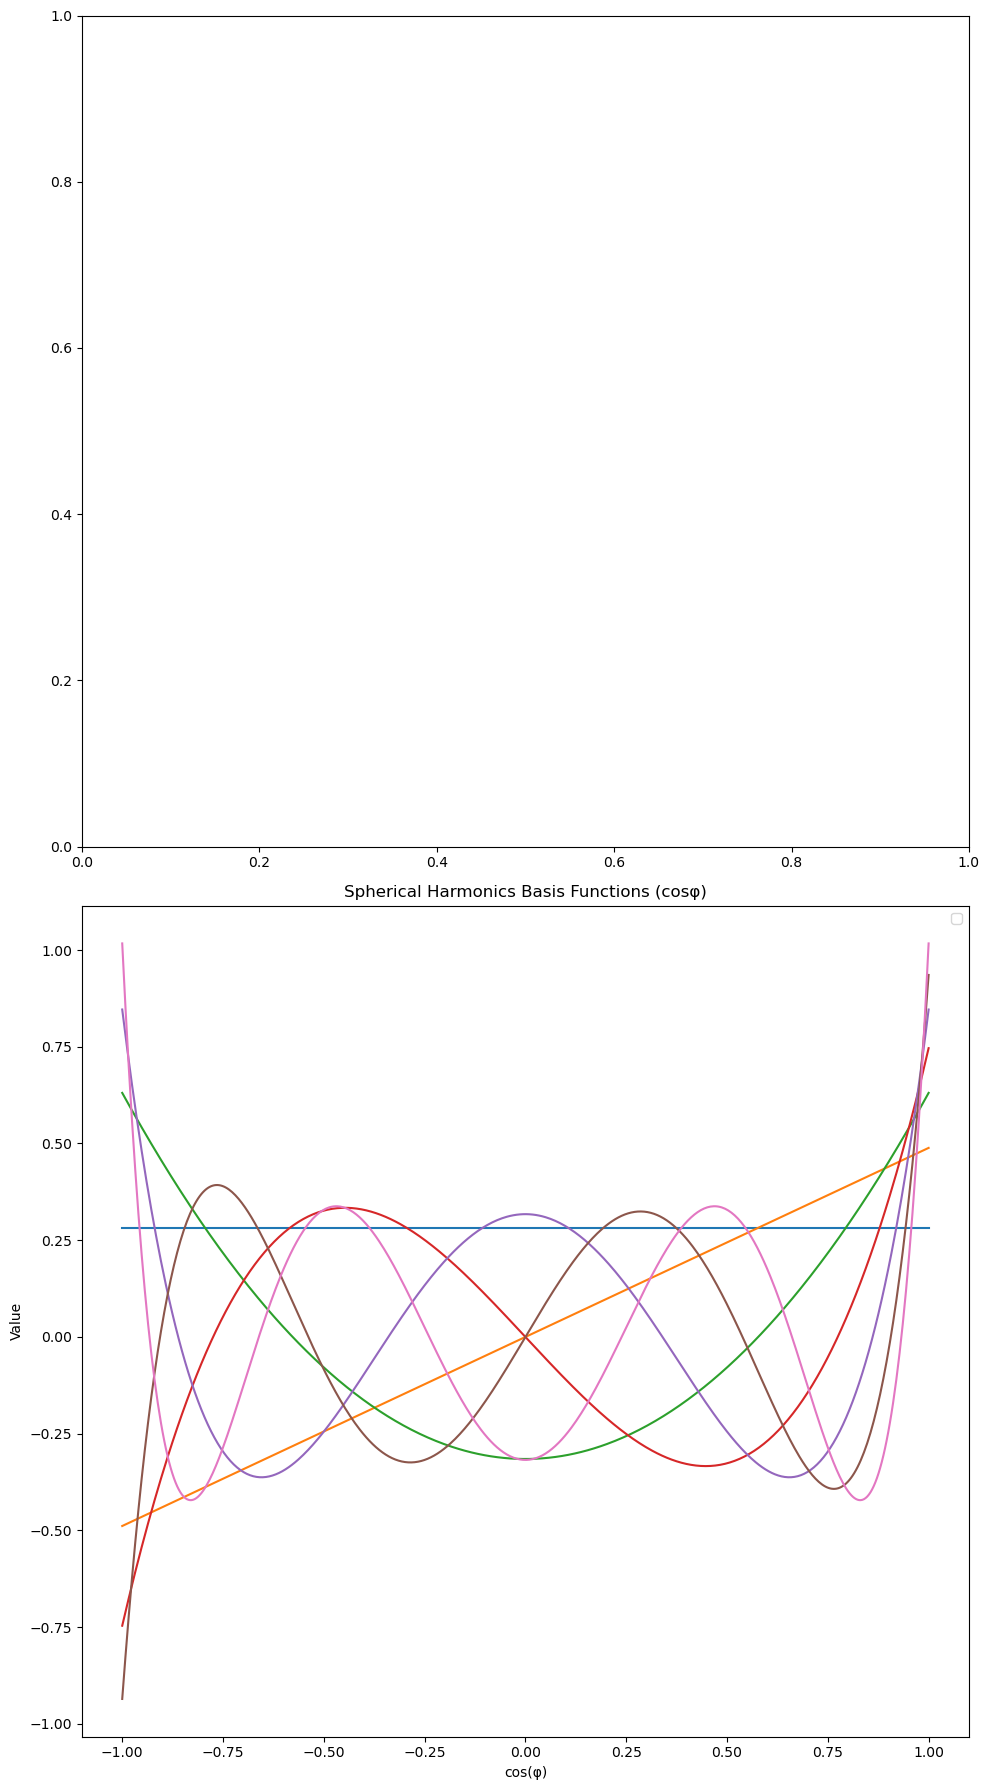

In [73]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import legendre
import sympy as sym
import math
import matplotlib.colors as mcolors

# RadialBasis的简化示例，用高斯RBF
class RadialBasis:
    def __init__(self, num_radial, cutoff):
        self.num_radial = num_radial
        self.cutoff = cutoff
        self.centers = torch.linspace(0, 1, num_radial)
        self.width = 10

    def __call__(self, d):
        # 输入d是距离张量，先归一化
        d_scaled = d / self.cutoff
        # 计算高斯基函数响应
        res = torch.exp(-self.width * (d_scaled[:, None] - self.centers[None, :]) ** 2)
        return res
def sph_harm_prefactor(l_degree: int, m_order: int):
    """
    Computes the constant pre-factor for the spherical harmonic
    of degree l and order m.

    Arguments
    ---------
    l_degree: int
        Degree of the spherical harmonic. l >= 0
    m_order: int
        Order of the spherical harmonic. -l <= m <= l

    Returns
    -------
    factor: float

    """
    # sqrt((2*l+1)/4*pi * (l-m)!/(l+m)! )
    return (
        (2 * l_degree + 1)
        / (4 * np.pi)
        * math.factorial(l_degree - abs(m_order))
        / math.factorial(l_degree + abs(m_order))
    ) ** 0.5

def associated_legendre_polynomials(
    L_maxdegree: int, zero_m_only: bool = True, pos_m_only: bool = True
):
    """
    Computes string formulas of the associated legendre polynomials
    up to degree L (excluded).

    Arguments
    ---------
    L_maxdegree: int
        Degree up to which to calculate the associated legendre polynomials
        (degree L is excluded).
    zero_m_only: bool
        If True only calculate the polynomials for the polynomials where m=0.
    pos_m_only: bool
        If True only calculate the polynomials for the polynomials where m>=0.
        Overwritten by zero_m_only.

    Returns
    -------
    polynomials: list
        Contains the sympy functions of the polynomials
        (in total L many if zero_m_only is True else L^2 many).
    """
    # calculations from http://web.cmb.usc.edu/people/alber/Software/tomominer/docs/cpp/group__legendre__polynomials.html
    z = sym.symbols("z", real=True)
    P_l_m = [
        [0] * (2 * l_degree + 1) for l_degree in range(L_maxdegree)
    ]  # for order l: -l <= m <= l

    P_l_m[0][0] = 1
    if L_maxdegree > 1:
        if zero_m_only:
            # m = 0
            P_l_m[1][0] = z
            for l_degree in range(2, L_maxdegree):
                P_l_m[l_degree][0] = sym.simplify(
                    (
                        (2 * l_degree - 1) * z * P_l_m[l_degree - 1][0]
                        - (l_degree - 1) * P_l_m[l_degree - 2][0]
                    )
                    / l_degree
                )
            return P_l_m
        else:
            # for m >= 0
            for l_degree in range(1, L_maxdegree):
                P_l_m[l_degree][l_degree] = sym.simplify(
                    (1 - 2 * l_degree)
                    * (1 - z**2) ** 0.5
                    * P_l_m[l_degree - 1][l_degree - 1]
                )  # P_00, P_11, P_22, P_33

            for m_order in range(0, L_maxdegree - 1):
                P_l_m[m_order + 1][m_order] = sym.simplify(
                    (2 * m_order + 1) * z * P_l_m[m_order][m_order]
                )  # P_10, P_21, P_32, P_43

            for l_degree in range(2, L_maxdegree):
                for m_order in range(l_degree - 1):  # P_20, P_30, P_31
                    P_l_m[l_degree][m_order] = sym.simplify(
                        (
                            (2 * l_degree - 1)
                            * z
                            * P_l_m[l_degree - 1][m_order]
                            - (l_degree + m_order - 1)
                            * P_l_m[l_degree - 2][m_order]
                        )
                        / (l_degree - m_order)
                    )

            if not pos_m_only:
                # for m < 0: P_l(-m) = (-1)^m * (l-m)!/(l+m)! * P_lm
                for l_degree in range(1, L_maxdegree):
                    for m_order in range(
                        1, l_degree + 1
                    ):  # P_1(-1), P_2(-1) P_2(-2)
                        P_l_m[l_degree][-m_order] = sym.simplify(
                            (-1) ** m_order
                            * math.factorial(l_degree - m_order)
                            / math.factorial(l_degree + m_order)
                            * P_l_m[l_degree][m_order]
                        )

            return P_l_m
def real_sph_harm(
    L_maxdegree: int,
    use_theta: bool,
    use_phi: bool = True,
    zero_m_only: bool = True,
) -> None:
    """
    Computes formula strings of the the real part of the spherical harmonics
    up to degree L (excluded). Variables are either spherical coordinates phi
    and theta (or cartesian coordinates x,y,z) on the UNIT SPHERE.

    Arguments
    ---------
    L_maxdegree: int
        Degree up to which to calculate the spherical harmonics
        (degree L is excluded).
    use_theta: bool
        - True: Expects the input of the formula strings to contain theta.
        - False: Expects the input of the formula strings to contain z.
    use_phi: bool
        - True: Expects the input of the formula strings to contain phi.
        - False: Expects the input of the formula strings to contain x and y.
        Does nothing if zero_m_only is True
    zero_m_only: bool
        If True only calculate the harmonics where m=0.

    Returns
    -------
    Y_lm_real: list
        Computes formula strings of the the real part of the spherical
        harmonics up to degree L (where degree L is not excluded).
        In total L^2 many sph harm exist up to degree L (excluded).
        However, if zero_m_only only is True then the total count
        is reduced to L.
    """
    z = sym.symbols("z", real=True)
    P_l_m = associated_legendre_polynomials(L_maxdegree, zero_m_only)
    if zero_m_only:
        # for all m != 0: Y_lm = 0
        Y_l_m = [[0] for l_degree in range(L_maxdegree)]
    else:
        Y_l_m = [
            [0] * (2 * l_degree + 1) for l_degree in range(L_maxdegree)
        ]  # for order l: -l <= m <= l

    # convert expressions to spherical coordiantes
    if use_theta:
        # replace z by cos(theta)
        theta = sym.symbols("theta", real=True)
        for l_degree in range(L_maxdegree):
            for m_order in range(len(P_l_m[l_degree])):
                if not isinstance(P_l_m[l_degree][m_order], int):
                    P_l_m[l_degree][m_order] = P_l_m[l_degree][m_order].subs(
                        z, sym.cos(theta)
                    )

    ## calculate Y_lm
    # Y_lm = N * P_lm(cos(theta)) * exp(i*m*phi)
    #             { sqrt(2) * (-1)^m * N * P_l|m| * sin(|m|*phi)   if m < 0
    # Y_lm_real = { Y_lm                                           if m = 0
    #             { sqrt(2) * (-1)^m * N * P_lm * cos(m*phi)       if m > 0

    for l_degree in range(L_maxdegree):
        Y_l_m[l_degree][0] = sym.simplify(
            sph_harm_prefactor(l_degree, 0) * P_l_m[l_degree][0]
        )  # Y_l0

    if not zero_m_only:
        phi = sym.symbols("phi", real=True)
        for l_degree in range(1, L_maxdegree):
            # m > 0
            for m_order in range(1, l_degree + 1):
                Y_l_m[l_degree][m_order] = sym.simplify(
                    2**0.5
                    * (-1) ** m_order
                    * sph_harm_prefactor(l_degree, m_order)
                    * P_l_m[l_degree][m_order]
                    * sym.cos(m_order * phi)
                )
            # m < 0
            for m_order in range(1, l_degree + 1):
                Y_l_m[l_degree][-m_order] = sym.simplify(
                    2**0.5
                    * (-1) ** m_order
                    * sph_harm_prefactor(l_degree, -m_order)
                    * P_l_m[l_degree][m_order]
                    * sym.sin(m_order * phi)
                )

        # convert expressions to cartesian coordinates
        if not use_phi:
            # replace phi by atan2(y,x)
            x, y = sym.symbols("x y", real=True)
            for l_degree in range(L_maxdegree):
                for m_order in range(len(Y_l_m[l_degree])):
                    Y_l_m[l_degree][m_order] = sym.simplify(
                        Y_l_m[l_degree][m_order].subs(phi, sym.atan2(y, x))
                    )
    return Y_l_m

# 球谐基函数，0阶m=0，用scipy的Legendre多项式
def get_sph_harm_basis(L_maxdegree: int, zero_m_only: bool = True):
    """Get a function calculating the spherical harmonics basis from z and phi."""
    # retrieve equations
    Y_lm = real_sph_harm(
        L_maxdegree, use_theta=False, use_phi=True, zero_m_only=zero_m_only
    )
    Y_lm_flat = [Y for Y_l in Y_lm for Y in Y_l]

    # convert to pytorch functions
    z = sym.symbols("z", real=True)
    variables = [z]
    if not zero_m_only:
        variables.append(sym.symbols("phi", real=True))

    modules = {"sin": torch.sin, "cos": torch.cos, "sqrt": torch.sqrt}
    sph_funcs = sym.lambdify(variables, Y_lm_flat, modules)

    # Return as a single function
    # args are either [cosφ] or [cosφ, ϑ]
    def basis_fn(*args) -> torch.Tensor:
        basis = sph_funcs(*args)
        basis[0] = args[0].new_tensor(basis[0]).expand_as(args[0])
        return torch.stack(basis, dim=1)

    return basis_fn


# CircularBasisLayer简化版，组合径向和角度基函数
class CircularBasisLayer(torch.nn.Module):
    def __init__(self, num_spherical, radial_basis, cbf, scale_basis=False):
        super().__init__()
        self.radial_basis = radial_basis
        self.scale_basis = scale_basis
        cbf_name = cbf["name"].lower()
        if cbf_name == "spherical_harmonics":
            self.cos_phi_basis = get_sph_harm_basis(num_spherical, zero_m_only=True)
        else:
            raise ValueError(f"Unknown cosine basis function '{cbf_name}'.")

    def forward(self, D_ca, cos_phi_cab):
        rad_basis = self.radial_basis(D_ca)
        cir_basis = self.cos_phi_basis(cos_phi_cab)
        return rad_basis, cir_basis

# 模拟输入
num_spherical = 7
num_radial = 16
cutoff = 6.0

D_ca = torch.linspace(0, cutoff, 500)
cos_phi_cab = torch.linspace(-1, 1, 500)

# 初始化
radial_basis = RadialBasis(num_radial=num_radial, cutoff=cutoff)
cbf = {"name": "spherical_harmonics"}
circular_basis_layer = CircularBasisLayer(num_spherical=num_spherical, radial_basis=radial_basis, cbf=cbf)

# 前向计算
rbf_vals, cbf_vals = circular_basis_layer(D_ca, cos_phi_cab)

# 绘图
fig, axs = plt.subplots(2, 1, figsize=(10, 18))

# # 径向基函数图
# for i in range(num_radial):
#     axs[0].plot(D_ca.numpy(), rbf_vals[:, i].numpy(), label=f'RBF {i}')
# axs[0].set_title("Radial Basis Functions")
# axs[0].set_xlabel("Distance (Å)")
# axs[0].set_ylabel("Value")
# axs[0].grid(True)
colors_list = ["#d7312d", "#f2724d", "#fee395", "#fef9b7", "#acd2e5", "#6090c1"]
# 球谐角度基函数图
for i in range(num_spherical):
    axs[1].plot(cos_phi_cab.numpy(), cbf_vals[:, i].numpy())
axs[1].set_title("Spherical Harmonics Basis Functions (cosφ)")
axs[1].set_xlabel("cos(φ)")
axs[1].set_ylabel("Value")
# axs[1].grid(True)

plt.tight_layout()
plt.legend()
plt.show()

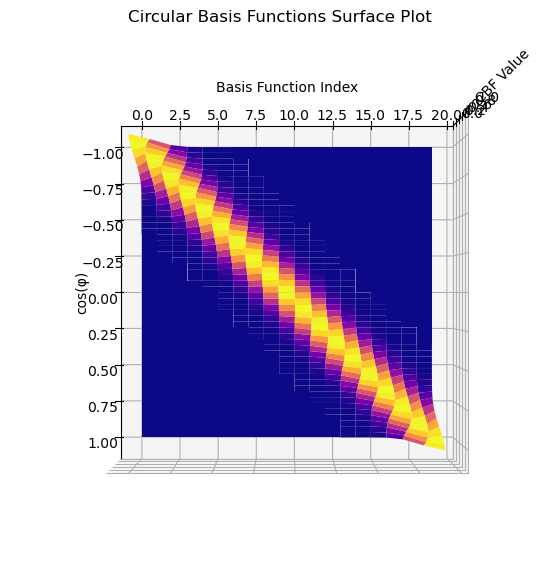

In [58]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 needed for 3d projection
import numpy as np
import matplotlib.pyplot as plt

cos_phi = np.linspace(-1, 1, 600)
num_cbf = 20
centers_c = np.linspace(-1, 1, num_cbf)
width_c = 40

cbf_vals = np.exp(-width_c * (cos_phi[:, None] - centers_c[None, :]) ** 2)

X, Y = np.meshgrid(cos_phi, np.arange(num_cbf))

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, cbf_vals.T, cmap='plasma')
ax.set_xlabel('cos(φ)')
ax.set_ylabel('Basis Function Index')
ax.set_zlabel('CBF Value')
ax.set_title('Circular Basis Functions Surface Plot')
ax.view_init(azim=0, elev=90)
plt.show()


Plotting Radial Basis...


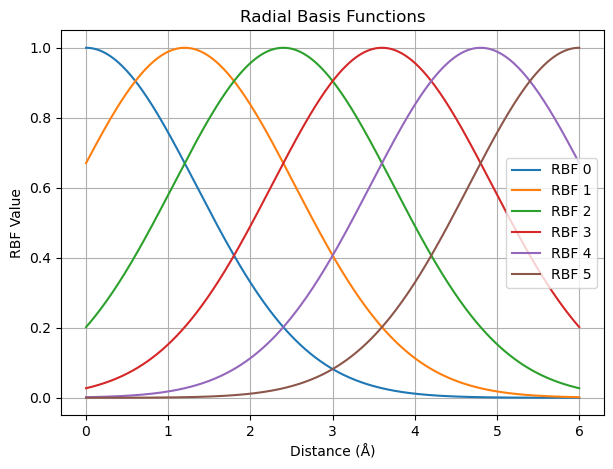

Plotting Spherical Basis (Gaussian Outer)...


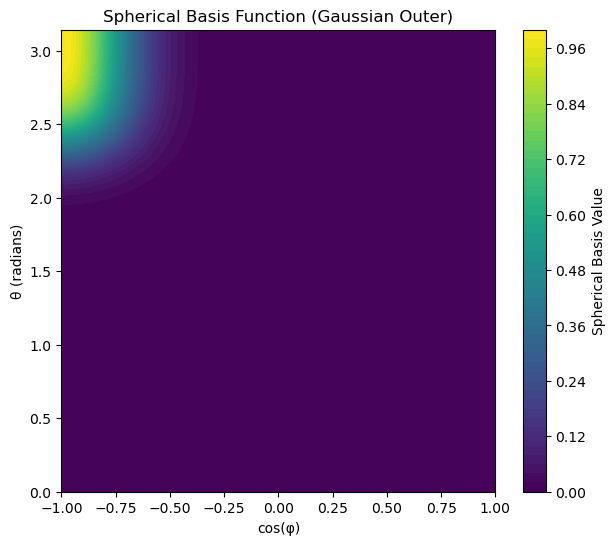

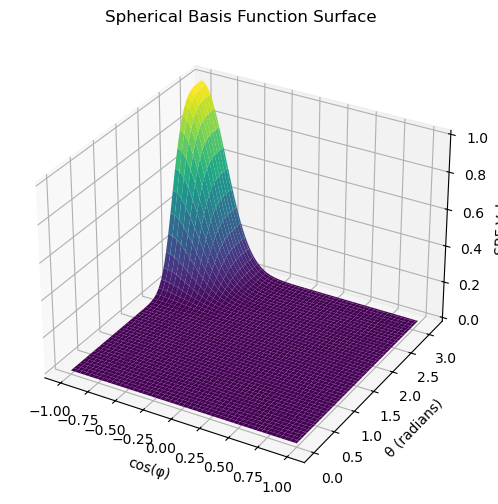

Plotting Spherical Harmonics (Example l=2, m=1)...


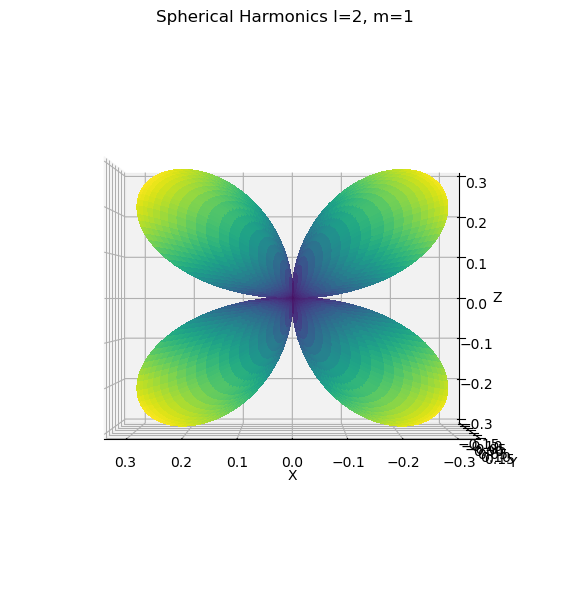

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import sph_harm


# =====================
# 1. Radial Basis
# =====================
def gaussian_rbf(d_scaled, centers, width):
    return np.exp(-width * (d_scaled[:, None] - centers[None, :]) ** 2)


def plot_radial_basis():
    cutoff = 6.0
    d = np.linspace(0, cutoff, 500)
    d_scaled = d / cutoff

    num_radial = 6
    centers = np.linspace(0, 1, num_radial)
    width = 10

    rbf = gaussian_rbf(d_scaled, centers, width)

    plt.figure(figsize=(7, 5))
    for i in range(num_radial):
        plt.plot(d, rbf[:, i], label=f'RBF {i}')
    plt.title('Radial Basis Functions')
    plt.xlabel('Distance (Å)')
    plt.ylabel('RBF Value')
    plt.legend()
    plt.grid()
    plt.show()


# =====================
# 2. Spherical Basis (Gaussian Outer)
# =====================
def gaussian_basis(x, centers, width):
    return np.exp(-width * (x[..., None] - centers) ** 2)


def plot_spherical_basis_gaussian_outer():
    cos_phi = np.linspace(-1, 1, 100)
    theta = np.linspace(0, np.pi, 100)
    cos_phi_grid, theta_grid = np.meshgrid(cos_phi, theta)

    num_spherical = 4
    centers = np.linspace(-1, 1, num_spherical)
    width = 10

    cbf_phi = gaussian_basis(cos_phi_grid, centers, width)
    cbf_theta = gaussian_basis(np.cos(theta_grid), centers, width)

    sbf = cbf_phi[..., :, None] * cbf_theta[..., None, :]
    sbf_flat = sbf.reshape(100, 100, -1)

    # 2D heatmap
    plt.figure(figsize=(7, 6))
    plt.contourf(cos_phi_grid, theta_grid, sbf_flat[..., 0],
                 levels=50, cmap='viridis')
    plt.colorbar(label='Spherical Basis Value')
    plt.xlabel('cos(φ)')
    plt.ylabel('θ (radians)')
    plt.title('Spherical Basis Function (Gaussian Outer)')
    plt.show()

    # 3D surface
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(cos_phi_grid, theta_grid, sbf_flat[..., 0],
                    cmap='viridis', edgecolor='none')

    ax.set_xlabel('cos(φ)')
    ax.set_ylabel('θ (radians)')
    ax.set_zlabel('SBF Value')
    ax.set_title('Spherical Basis Function Surface')
    plt.show()


# =====================
# 3. Spherical Harmonics (真实球谐函数)
# =====================
def plot_spherical_harmonics(l=2, m=1):
    theta = np.linspace(0, np.pi, 100)      # polar angle
    phi = np.linspace(0, 2 * np.pi, 100)    # azimuthal angle
    phi_grid, theta_grid = np.meshgrid(phi, theta)

    # 球谐函数
    Y = sph_harm(m, l, phi_grid, theta_grid)
    Y_magnitude = np.abs(Y.real)

    # 球坐标 -> 笛卡尔
    r = Y_magnitude
    X = r * np.sin(theta_grid) * np.cos(phi_grid)
    Y = r * np.sin(theta_grid) * np.sin(phi_grid)
    Z = r * np.cos(theta_grid)

    # 3D plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, facecolors=plt.cm.viridis(r / r.max()),
                    rstride=1, cstride=1, antialiased=False, shade=False)

    ax.set_title(f"Spherical Harmonics l={l}, m={m}")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(azim=90, elev=0)
    plt.tight_layout()
    plt.show()


# =====================
# 主函数
# =====================
if __name__ == '__main__':
    print("Plotting Radial Basis...")
    plot_radial_basis()

    print("Plotting Spherical Basis (Gaussian Outer)...")
    plot_spherical_basis_gaussian_outer()

    print("Plotting Spherical Harmonics (Example l=2, m=1)...")
    plot_spherical_harmonics(l=2, m=1)